In [2]:
import  math
from random import random

import numpy as np
import matplotlib.pyplot as plt
from fontTools.ttLib.ttVisitor import visit
from jinja2.filters import sync_do_select
from numpy.ma.core import shape, outer
%matplotlib inline

In [227]:
def f(x):
    return 3*x**2 -4*x +5

In [4]:
f(3.0)

20.0

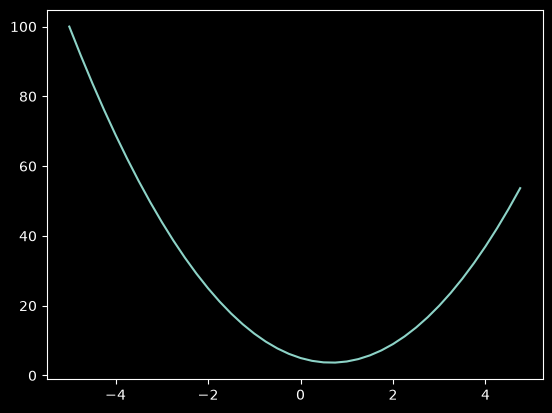

In [7]:
xs=np.arange(-5,5,0.25)  #范围，0.25间隔步长
xs
ys=f(xs)
plt.plot(xs,ys)

In [10]:
h =0.0000001
x=3.0
(f(x+h)-f(x))/h #等于斜率     要将上升量收减非常小，才能收减到精确值

14.000000305713911

In [11]:
#lest get more complex
a=2.0
b=-3.0
c=10.0
d=a*b +c
print(d)

4.0


In [18]:
h=0.0001
#impus
a=2.0
b=-3.0
c=10.0
d1=a*b +c
b+=h
d2=a*b +c
print(d1)
print(d2)
print('slope',(d2-d1)/h)

4.0
4.0002
slope 2.0000000000042206


In [189]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self._prev=set(_children)
        self._op=_op
        self._backward=lambda :None
        self.label=label
        self.grad=0
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')
        def _backward():
            self.grad=1.0*out.grad
            other.grad=1.0*out.grad
        out._backward=_backward
        return out
    def __radd__(self, other):
        return self + other
    def __mul__(self, other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')
        def _backward():
            self.grad=other.data*out.grad
            other.grad=self.data*out.grad
        out._backward=_backward
        return out
    def thanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')
        def _backward():
            self.grad=(1-t**2)*out.grad
        out._backward=_backward
        return out
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad=out.data*out.grad
        out._backward=_backward
        return out
    def __truediv__(self, other):
        return self * other **-1

    def __rmul__(self, other):
        return self*other
    def __sub__(self, other):
        return self + (-1 * other)
    def __pow__(self, other):
        assert isinstance(other,(int,float)),"only supporting int /float powers for now "
        out=Value(self.data**other,(self,),f'**{other}')
        def _backward():
            self.grad+=other* (self.data**(other-1)) * out.grad
        out._backward=_backward
        return out
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
            topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()

a=Value(2.0,label='a')
b=Value(-3.0,label='b')
c=Value(10.0,label='c')
e=a*b;e.label='e'
d=e + c;d.label='d'
f=Value(-2.0,label='f')
L=d*f

In [34]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [35]:
d._op

'+'

In [172]:
#表达式图 把一个数学表达式计算过程，转换成 Graphviz 可以画出来的“计算图”。
from graphviz import Digraph
#找出计算图里面所有节点和边。
def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes,edges=set(),set()
    def build(v):
        #如果这个节点还没有访问过。
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges
#把这些节点和边交给 Graphviz，让 Graphviz 画图。
#把刚才找到的计算图画出来。
def draw_dot(root):
    #SVG 是一种矢量图。所以放大不会像普通 PNG 那样容易糊
    #如果没有这个设置，Graphviz 默认可能上下排列。
    dot=Digraph(format='svg',graph_attr={'rankdir':'LR'})#LR=left to right
    nodes , edges=trace(root)
    for n in nodes :
        uid=str(id(n))
        #for any value in the graph ,create  a rectangular ('record') node for it
        #用类似矩形信息框的形式显示。
        dot.node(name=uid,label="{%s | data %.4f |grad %.4f}"% (n.label,n.data,n.grad),shape='record')
        if n._op:
            #if this value is a result of some operation ,create an op node for it
            dot.node(name=uid+n._op,label=n._op)
            #and connect this node to it
            dot.edge(uid+n._op,uid)
    for n1,n2 in edges:
        #connect n1 to the op node of n2
        dot.edge(str(id(n1)),str(id(n2))+n2._op)
    return dot


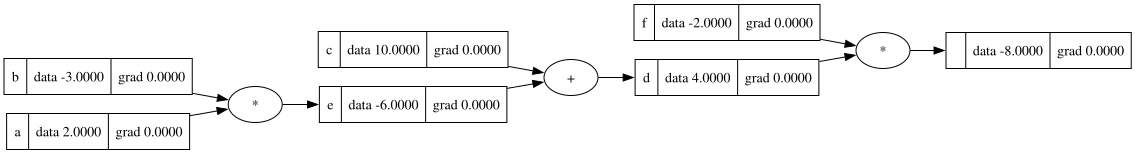

In [127]:
draw_dot(L)

In [123]:
L.grad=1.0

In [126]:
def lol():
    h=0.001
    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b;e.label='e'
    d=e + c;d.label='d'
    f=Value(-2.0,label='f')
    L=d*f;L.label='L'
    L1=L.data


    a=Value(2.0,label='a')
    b=Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e=a*b;e.label='e'
    d=e + c;d.label='d'
    d.data+=h
    f=Value(-2.0,label='f')
    L=d*f;L.label='L'
    L2=L.data
    print((L2-L1)/h)

lol()


-2.000000000000668


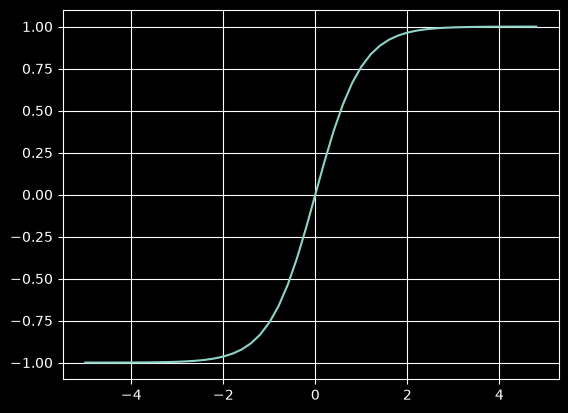

In [81]:
#plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid()
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2)));plt.grid()

In [132]:
# inputs x1,x2
x1 = Value(2.0,
label='x1')
x2 = Value(8.0,
label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.7, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2=x2*w2; x2w2.label = 'x2ww2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2*'
n = x1w1x2w2 + b; n.label = 'n'
o = n.thanh();o.label='o'

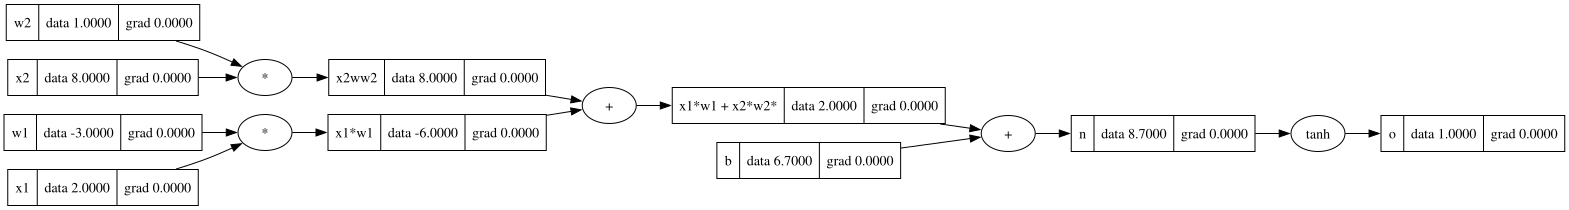

In [133]:
draw_dot (o)


In [130]:

o.backward()

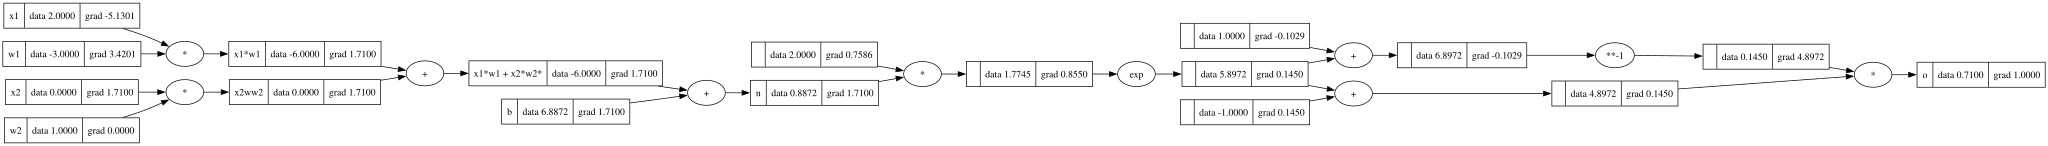

In [142]:
x1 = Value(2.0,
label='x1')
x2 = Value(0.0,
label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88723612631, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2=x2*w2; x2w2.label = 'x2ww2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2*'
n = x1w1x2w2 + b; n.label = 'n'
e=(2*n).exp()
o=(e-1)/(e+1)
o.label='o'
o.backward()
draw_dot(o)

In [144]:
import torch

In [145]:
x1 = torch.Tensor([2.0]).double(); x1. requires_grad=True
x2 = torch.Tensor( [0.0]).double()  ;x2. requires_grad = True
w1 = torch.Tensor([-3.0]).double();w1. requires_grad=True
w2 = torch.Tensor( [1.0]).double();w2. requires_grad = True
b = torch.Tensor( [6.8813735878195432]).double(); b. requires_grad = True
n= x1*w1 + x2*w2 + b
o= torch. tanh(n)

print(o.data.item())
o.backward()
print('-- ')
print('x2'
, x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('wl', w1.grad.item())

0.7071066904050358
-- 
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
wl 1.0000002567688737


In [197]:
import random
class Neuron:
    def __init__(self,nin ):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    def __call__(self, x):
        act=sum((wi * xi for wi ,xi in zip(self.w,x)),self.b)
        out=act.thanh()
        return  out
    def parameters(self):
        return self.w + [self.b]

x=[2.0,3.0]
n=Neuron(2)
n(x)

Value(data=0.9542510282028335)

In [198]:
class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self, x):
        outs=[n(x) for n in self.neurons]
        return outs
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
#x=[2.0,3.0]
#n=Layer(3,5)

#n(x)

x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])

n(x)

[Value(data=-0.45968486044347584)]

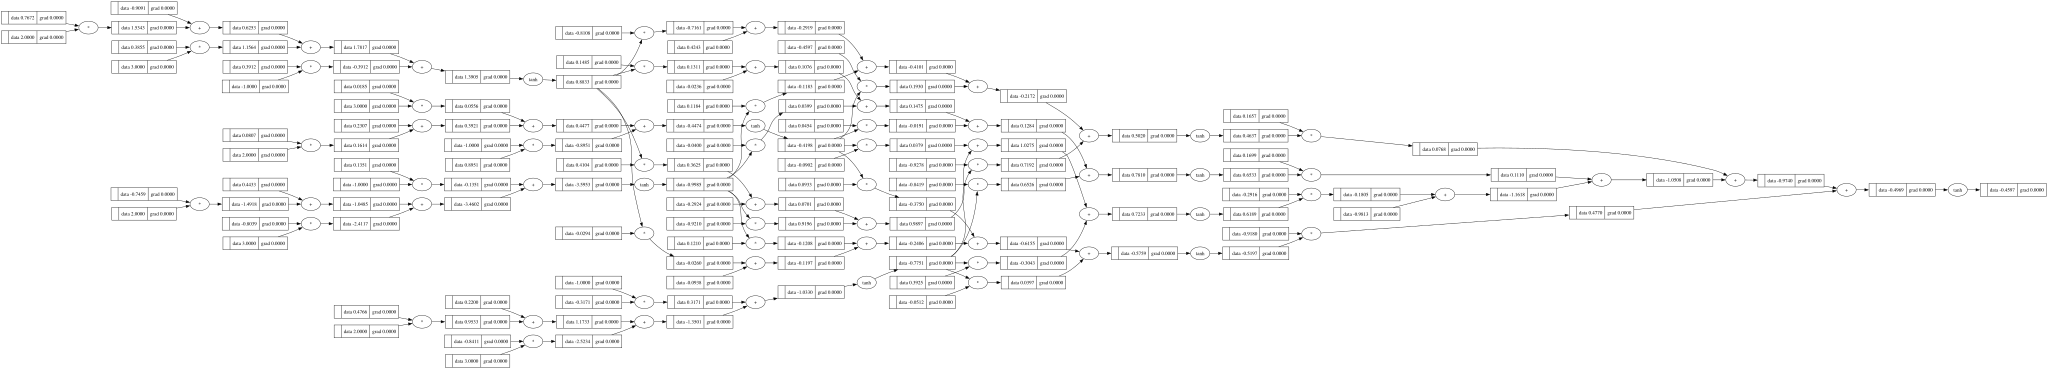

In [199]:
draw_dot(n(x)[0])

In [200]:
xs=[[2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]]
ys=[1.0,-1.0,-1.0,1.0]


[Value(data=-0.45968486044347584),
 Value(data=-0.9463282159791346),
 Value(data=-0.869678314581574),
 Value(data=-0.4978056384530165)]

In [215]:
for k in range(20):

    yped=[n(x)[0] for x in xs]
    loss=sum([(yout-ygt)**2 for ygt ,yout in zip(ys,yped)])
    #backward pass 梯度清零
    for p in n.parameters():
        p.grad=0.0
    loss.backward()
#update
    #梯度下降的方案的微小更新
    for p in n.parameters():
        p.data+=-0.05*p.grad
    print(k,loss.data)

Value(data=7.839395547428532)

In [202]:
loss.backward()

In [203]:
n.layers[0].neurons[0].w[0].grad

0.22868024918122556

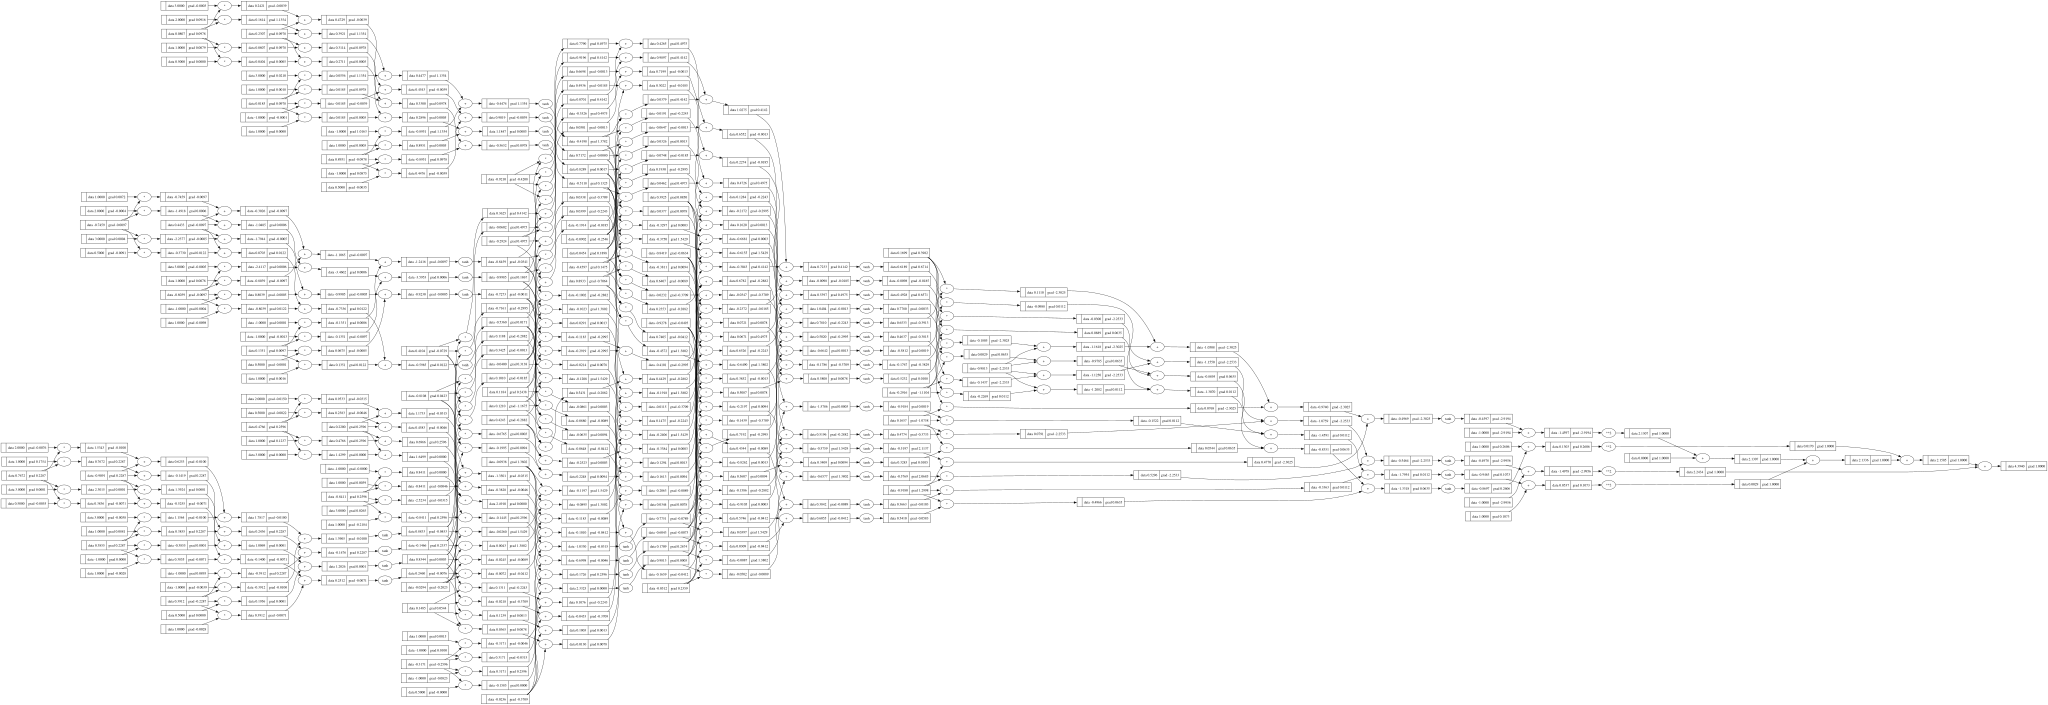

In [204]:
draw_dot(loss)

In [216]:
n.layers[0].neurons[0].w[0].data

0.8357705397855548

In [224]:
#梯度下降的方案的微小更新
for p in n.parameters():
    p.data+=0.01*p.grad

In [225]:
n.layers[0].neurons[0].w[0].data


0.8860801946054244

# 🏭 生产实战案例（micrograd → 真实工程）

下面这一节把前面的玩具 `Value` / `MLP` 和**真实生产里天天用的操作**对应起来。
每个案例都是「概念 → 会踩的坑 → 生产正确写法 → 和 PyTorch 对照验证」。
你可以顺手在后面接着写自己的案例。


## 案例 1：梯度累加 bug —— `+=` vs `=`（这是本 notebook 上面 cell 7 里真实存在的 bug）

看上面 cell 7 的 `Value`：`__add__` / `__mul__` / `tanh` 的 `_backward` 里写的是
`self.grad = ... * out.grad`（**用 `=` 覆盖**），只有 `__pow__` 用了 `+=`。

**为什么这是 bug：** 反向传播里，如果一个节点被用了**多次**（fan-out，比如 `a + a`，或同一个权重连到多个输出），
根据多元链式法则，它的梯度应该是**各条路径的梯度之和**。用 `=` 会让后算的路径**覆盖**前一条，梯度就错了。
这是自己写 autograd / 自定义 `torch.autograd.Function` 时最常见、最难查的一类 bug。


In [ ]:
# 复刻“有 bug”的版本（=覆盖）对比“生产正确”版本（+=累加）
class ValueBug:
    def __init__(self, data, _children=()):
        self.data=data; self._prev=set(_children); self._backward=lambda:None; self.grad=0
    def __add__(self, o):
        o=o if isinstance(o,ValueBug) else ValueBug(o)
        out=ValueBug(self.data+o.data,(self,o))
        def _b():
            self.grad = 1.0*out.grad     # ❌ 覆盖
            o.grad    = 1.0*out.grad
        out._backward=_b; return out
    def backward(self):
        topo=[]; vis=set()
        def bt(v):
            if v not in vis:
                vis.add(v)
                for c in v._prev: bt(c)
                topo.append(v)
        bt(self); self.grad=1.0
        for n in reversed(topo): n._backward()

class ValueOK:
    def __init__(self, data, _children=()):
        self.data=data; self._prev=set(_children); self._backward=lambda:None; self.grad=0.0
    def __add__(self, o):
        o=o if isinstance(o,ValueOK) else ValueOK(o)
        out=ValueOK(self.data+o.data,(self,o))
        def _b():
            self.grad += out.grad        # ✅ 累加
            o.grad    += out.grad
        out._backward=_b; return out
    def backward(self):
        topo=[]; vis=set()
        def bt(v):
            if v not in vis:
                vis.add(v)
                for c in v._prev: bt(c)
                topo.append(v)
        bt(self); self.grad=1.0
        for n in reversed(topo): n._backward()

a=ValueBug(3.0); (a+a).backward(); print("bug 版  d(a+a)/da =", a.grad, "  应为 2")
a=ValueOK(3.0);  (a+a).backward(); print("正确版  d(a+a)/da =", a.grad)

import torch
at=torch.tensor(3.0, requires_grad=True); (at+at).backward()
print("torch   d(a+a)/da =", at.grad.item())
# 👉 结论：所有 _backward 里都要用 += ；上面 cell 7 请把 = 改成 +=


## 案例 2：数值稳定的 softmax / 交叉熵（log-sum-exp 技巧）

分类任务里 `exp()` 极易 **overflow**：`logits` 稍微大一点（比如 1000）`np.exp` 直接变 `inf → nan`。
注意上面 cell 7 的 `tanh` 用了 `math.exp(2*x)`，`x` 大时同样会炸。

**生产做法：** softmax 前先减去 `max(logits)`（结果不变，因为 softmax 平移不变），
交叉熵用 `log-softmax = z - logsumexp(z)` 一步算，避免先 exp 再 log。这就是 PyTorch `cross_entropy` 内部做的事。


In [ ]:
import numpy as np, torch

logits = np.array([1000., 1001., 1002.])
naive = np.exp(logits)/np.exp(logits).sum()     # 会数值溢出 -> 变成 inf/nan
print("naive softmax :", naive)

def softmax(z):
    z = z - z.max()                              # 关键：减最大值
    e = np.exp(z); return e/e.sum()
def log_softmax(z):
    z = z - z.max()
    return z - np.log(np.exp(z).sum())
def cross_entropy(logits, target):               # target 是类别下标
    return -log_softmax(logits)[target]

print("stable softmax:", softmax(logits))
print("cross_entropy :", cross_entropy(logits, target=2))
tl = torch.tensor([[1000.,1001.,1002.]])
print("torch CE      :", torch.nn.functional.cross_entropy(tl, torch.tensor([2])).item())


## 案例 3：PyTorch 生产版训练循环（对应上面 cell 21–25 的手写 MLP）

上面手写训练循环缺了生产里必备的几件事，这里补全，用的是同一个 4 样本玩具数据：

- `optimizer.zero_grad()`：**每步清零梯度**（否则会累加——正是案例 1 的 `+=` 语义）
- `Adam` 优化器 + **学习率调度器**（`StepLR`）
- **梯度裁剪** `clip_grad_norm_`：防梯度爆炸（RNN/Transformer 必备）
- `model.train()` / `model.eval()`：切换 dropout / batchnorm 行为


In [ ]:
import torch
torch.manual_seed(0)

X = torch.tensor([[2.0,3.0,-1.0],[3.0,-1.0,0.5],[0.5,1.0,1.0],[1.0,1.0,-1.0]])
Y = torch.tensor([1.0,-1.0,-1.0,1.0]).unsqueeze(1)

model = torch.nn.Sequential(
    torch.nn.Linear(3,4), torch.nn.Tanh(),
    torch.nn.Linear(4,4), torch.nn.Tanh(),
    torch.nn.Linear(4,1), torch.nn.Tanh(),
)                                       # 等价于 MLP(3,[4,4,1])
opt   = torch.optim.Adam(model.parameters(), lr=0.05)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=40, gamma=0.5)
lossf = torch.nn.MSELoss()

for epoch in range(80):
    model.train()
    opt.zero_grad()                     # 1) 清零（对应手写的 p.grad=0.0）
    loss = lossf(model(X), Y)           # 2) 前向 + 计算损失
    loss.backward()                     # 3) 反向
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # 4) 梯度裁剪
    opt.step()                          # 5) 更新（对应 p.data += -lr*p.grad）
    sched.step()                        # 6) 调整学习率
    if epoch % 20 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.5f}  lr {sched.get_last_lr()[0]:.4f}")

model.eval()
with torch.no_grad():
    print("preds:", [round(v,3) for v in model(X).squeeze().tolist()])


## 案例 4：梯度检验（gradient checking）—— 上线自定义算子前的标准验证

自己写反向传播（案例 1 那种 `_backward`）怎么确认没写错？生产标准做法是**数值梯度对照**：
用有限差分 `(f(x+ε) − f(x−ε)) / 2ε` 近似真实导数，和你解析求的梯度比 **相对误差**，`< 1e-5` 才敢信。
这正是本 notebook 最前面 cell 4–6 那个 `h=0.0001` 求斜率的思路，只不过用它来**验证 autograd**。


In [ ]:
import math

class V:  # 带 tanh 的正确版 Value（+= 累加）
    def __init__(self, data, _children=()):
        self.data=data; self._prev=set(_children); self._backward=lambda:None; self.grad=0.0
    def __add__(self, o):
        o=o if isinstance(o,V) else V(o); out=V(self.data+o.data,(self,o))
        def _b(): self.grad+=out.grad; o.grad+=out.grad
        out._backward=_b; return out
    def __mul__(self, o):
        o=o if isinstance(o,V) else V(o); out=V(self.data*o.data,(self,o))
        def _b(): self.grad+=o.data*out.grad; o.grad+=self.data*out.grad
        out._backward=_b; return out
    def tanh(self):
        t=math.tanh(self.data); out=V(t,(self,))
        def _b(): self.grad+=(1-t*t)*out.grad
        out._backward=_b; return out
    def backward(self):
        topo=[]; vis=set()
        def bt(v):
            if v not in vis:
                vis.add(v)
                for c in v._prev: bt(c)
                topo.append(v)
        bt(self); self.grad=1.0
        for n in reversed(topo): n._backward()

def forward(xval):                 # 任意标量函数 f(x) = tanh(2x + 1)
    x=V(xval); return (x*2 + 1).tanh(), x

x0=0.7
y, x = forward(x0); y.backward()
analytic = x.grad
eps=1e-6
numeric = (math.tanh(2*(x0+eps)+1) - math.tanh(2*(x0-eps)+1))/(2*eps)
rel_err = abs(analytic-numeric)/max(1e-12, abs(numeric))
print(f"analytic={analytic:.8f}  numeric={numeric:.8f}  rel_err={rel_err:.2e}")
assert rel_err < 1e-5, "梯度写错了！"
print("✅ 梯度检验通过")


## 案例 5：向量化 —— 从「标量 Value 引擎」到「张量」（生产为什么不用逐元素求导）

micrograd 每个数都是一个 Python 对象、每个 `+`/`*` 都建一个节点：教学清晰，但 **N×D×H 规模会创建上百万个对象**，慢几个数量级。
生产里一层线性层就是一个矩阵乘 `Y = X @ W`，前向/反向都用矩阵运算一次算完（下面手写反向，和链式法则完全一致）：

- forward:  `Y = X @ W`
- backward: `dW = Xᵀ @ dY`，`dX = dY @ Wᵀ`


In [ ]:
import numpy as np, time

N, D, H = 256, 64, 128
rng = np.random.default_rng(0)
X = rng.standard_normal((N, D))
W = rng.standard_normal((D, H))

t0 = time.time()
Y  = X @ W                      # 前向：一次矩阵乘 = N*D*H 次标量乘
dY = np.ones_like(Y)            # 假设上游梯度
dW = X.T @ dY                   # 反向（和 Value 的 __mul__ 链式法则一致，只是批量化）
dX = dY @ W.T
dt = (time.time()-t0)*1000
print(f"向量化 前向+反向: {dt:.2f} ms   dW{dW.shape}  dX{dX.shape}")
print(f"若用标量 Value 引擎需创建 ~{N*D*H:,} 个节点对象，慢几个数量级、内存也扛不住")

# 数值梯度抽查一个 W[i,j]，确认手写 dW 正确
i, j = 3, 5
eps = 1e-5
Wp = W.copy(); Wp[i,j]+=eps; Wm = W.copy(); Wm[i,j]-=eps
num = ((X@Wp).sum() - (X@Wm).sum())/(2*eps)   # loss=Y.sum() 时 dY=全1
print(f"dW[{i},{j}] analytic={dW[i,j]:.4f}  numeric={num:.4f}")
